# Parte 3: Modelagem de Regressão (Simples e Múltipla)
Este notebook foca na construção, estimação e inferência dos modelos estatísticos 
para explicar os fatores que influenciam o valor bruto da Agropecuária brasileira.

In [1]:
import sys
from pathlib import Path

# Adicionar o diretório raiz do projeto ao path para importar config
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from config import PIB_MUNICIPIOS_PROCESSED

# Configurações de exibição
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Carregando os dados limpos
df = pd.read_csv(PIB_MUNICIPIOS_PROCESSED)
print(f"Dados carregados com sucesso: {df.shape[0]} registros.")

# Identificação dinâmica das colunas (evitando KeyErrors com quebras de linha)
def encontrar_coluna(termo):
    return [c for c in df.columns if termo in c][0]

col_agro = encontrar_coluna('Agropecuária')
col_ind = encontrar_coluna('Indústria')
col_serv = encontrar_coluna('Serviços')
col_adm = encontrar_coluna('Administração')

print(f"\nColunas identificadas:")
print(f"  Agropecuária: {col_agro}")
print(f"  Indústria: {col_ind}")
print(f"  Serviços: {col_serv}")
print(f"  Administração: {col_adm}")

Dados carregados com sucesso: 66825 registros.

Colunas identificadas:
  Agropecuária: Valor adicionado bruto da Agropecuária, 
a preços correntes
(R$ 1.000)
  Indústria: Valor adicionado bruto da Indústria,
a preços correntes
(R$ 1.000)
  Serviços: Valor adicionado bruto dos Serviços,
a preços correntes 
- exceto Administração, defesa, educação e saúde públicas e seguridade social
(R$ 1.000)
  Administração: Valor adicionado bruto dos Serviços,
a preços correntes 
- exceto Administração, defesa, educação e saúde públicas e seguridade social
(R$ 1.000)


## 1. Divisão em Amostras de Treinamento e Teste
Conforme exigido no item 3.4 do trabalho, utilizaremos amostras de treino e teste 
para garantir a validação e capacidade de generalização do modelo.

In [2]:
# Definindo variáveis explicativas (X) e alvo (y)
X = df[[col_ind, col_serv, col_adm]]
y = df[col_agro]

# Adicionando a constante (intercepto b0) obrigatória para o modelo linear
X = sm.add_constant(X)

# Divisão 80% treinamento / 20% teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Amostra de Treino: {len(X_train)} municípios")
print(f"Amostra de Teste: {len(X_test)} municípios")

Amostra de Treino: 53460 municípios
Amostra de Teste: 13365 municípios


## 2. Modelo de Regressão Linear Múltipla
Ajuste do modelo via Mínimos Quadrados Ordinários (MQO). 
Analisaremos a significância dos coeficientes e o R-quadrado ajustado.

In [3]:
modelo_multiplo = sm.OLS(y_train, X_train).fit()
print(modelo_multiplo.summary())

                                                      OLS Regression Results                                                      
Dep. Variable:     Valor adicionado bruto da Agropecuária, 
a preços correntes
(R$ 1.000)   R-squared:                       0.004
Model:                                                                                OLS   Adj. R-squared:                  0.004
Method:                                                                     Least Squares   F-statistic:                     120.3
Date:                                                                    Thu, 16 Apr 2026   Prob (F-statistic):           7.27e-53
Time:                                                                            23:48:27   Log-Likelihood:            -6.9849e+05
No. Observations:                                                                   53460   AIC:                         1.397e+06
Df Residuals:                                                                      

## 3. Avaliação da Qualidade do Modelo (Dados de Teste)
Validaremos o desempenho do modelo utilizando a amostra de teste que não foi vista no treinamento.

In [4]:
y_pred = modelo_multiplo.predict(X_test)

r2_test = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-quadrado (Amostra de Teste): {r2_test:.4f}")
print(f"RMSE (Erro Quadrático Médio da Raiz): {rmse:.2f}")

R-quadrado (Amostra de Teste): 0.0046
RMSE (Erro Quadrático Médio da Raiz): 109471.74


## 4. Diagnóstico de Resíduos
Verificação visual para validar as suposições clássicas: normalidade e homocedasticidade.

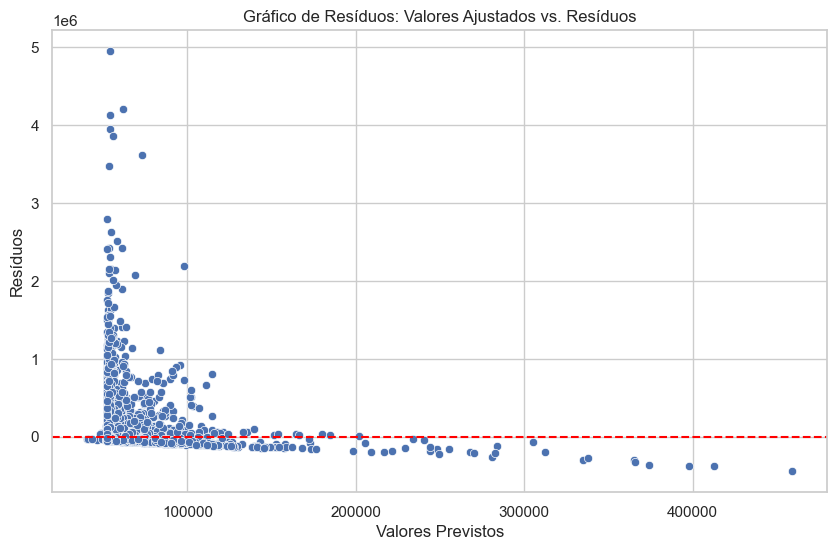

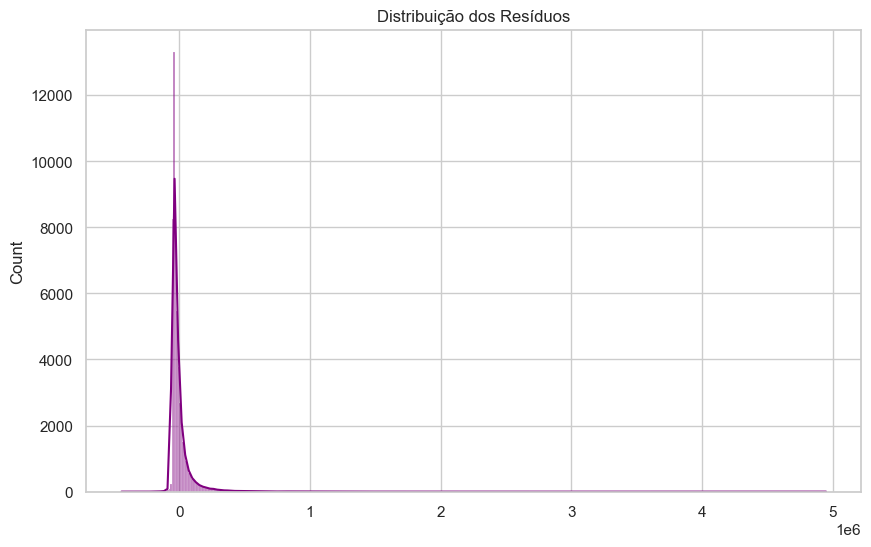

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=modelo_multiplo.fittedvalues, y=modelo_multiplo.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Gráfico de Resíduos: Valores Ajustados vs. Resíduos')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.show()

# Histograma dos Resíduos para verificar Normalidade
plt.figure(figsize=(10, 6))
sns.histplot(modelo_multiplo.resid, kde=True, color='purple')
plt.title('Distribuição dos Resíduos')
plt.show()